In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# CONFIG

N_QUBITS=5
N_LAYERS=3
INPUT_DIM=10
HIDDEN_DIM=64
BATCH_SIZE=32
N_EPOCHS=300
LR=1e-3

N_PARAMS=N_QUBITS * N_LAYERS
STATE_DIM=2**N_QUBITS

torch.manual_seed(24)
np.random.seed(24)

print("=" * 50)
print("STEP 1 -- CONFIG")
print("=" * 50)
print(f"  Qubits      : {N_QUBITS}")
print(f"  PQC layers  : {N_LAYERS}")
print(f"  Input dim   : {INPUT_DIM}")
print(f"  N_PARAMS    : {N_PARAMS}  (MLP output size)")
print(f"  STATE_DIM   : {STATE_DIM} (statevector length = 2^{N_QUBITS})")
print(f"  Batch size  : {BATCH_SIZE}")
print(f"  Epochs      : {N_EPOCHS}")
print(f"  LR          : {LR}")

STEP 1 -- CONFIG
  Qubits      : 5
  PQC layers  : 3
  Input dim   : 10
  N_PARAMS    : 15  (MLP output size)
  STATE_DIM   : 32 (statevector length = 2^5)
  Batch size  : 32
  Epochs      : 300
  LR          : 0.001


In [ ]:
# DATA GENERATION

def sample_inputs(batch_size:int, input_dim:int)-> torch.Tensor:
  return torch.randn(batch_size, input_dim)

def make_target_state(n_qubits:int)-> torch.Tensor:
  dim=2**n_qubits
  amplitude=1.0/np.sqrt(dim)
  state=np.full(dim,amplitude)
  return torch.Tensor(state,dtype=torch.float32)


In [ ]:
print("\n" + "=" * 50)
print("STEP 2 -- DATA GENERATION")
print("=" * 50)

# Check 1: input batch shape and distribution
x = sample_inputs(BATCH_SIZE, INPUT_DIM)

assert x.shape == (BATCH_SIZE, INPUT_DIM), \
    f"Wrong input shape: {x.shape}"
assert x.dtype == torch.float32, \
    f"Wrong dtype: {x.dtype}"

mean_val = x.mean().item()
std_val  = x.std().item()
assert abs(mean_val) < 0.5, f"Mean too far from 0: {mean_val:.4f}"
assert 0.5 < std_val < 1.5, f"Std too far from 1: {std_val:.4f}"

print(f"\n  sample_inputs({BATCH_SIZE}, {INPUT_DIM})")
print(f"    shape  : {x.shape}        OK")
print(f"    dtype  : {x.dtype}   OK")
print(f"    mean   : {mean_val:+.4f}         (expect near 0)")
print(f"    std    : {std_val:.4f}         (expect near 1)")

def make_target_state(n_qubits: int) -> torch.Tensor:

    dim = 2 ** n_qubits
    amplitude = 1.0 / np.sqrt(dim)
    return torch.tensor(
        np.full(dim, amplitude, dtype=np.float32)
    )


# ── Sanity check ──────────────────────────────────────────────
target = make_target_state(N_QUBITS)
expected_amp = 1.0 / np.sqrt(STATE_DIM)

assert target.shape == (STATE_DIM,)
assert target.dtype == torch.float32
assert torch.allclose(target, torch.full((STATE_DIM,), expected_amp), atol=1e-6)

# Most important: sum(|psi|^2) must equal 1.0
prob_sum = (target ** 2).sum().item()
assert abs(prob_sum - 1.0) < 1e-5, f"Not normalised: {prob_sum}"

print(f"shape        : {target.shape}")
print(f"amplitude    : {target[0].item():.6f}  (= 1/sqrt({STATE_DIM}))")
print(f"sum(|psi|^2) : {prob_sum:.6f}  (must be exactly 1.0)")
print(f"all equal    : {torch.all(target == target[0]).item()}")
print("All assertions passed")

# Check 3: stochasticity -- different calls give different data
x1 = sample_inputs(BATCH_SIZE, INPUT_DIM)
x2 = sample_inputs(BATCH_SIZE, INPUT_DIM)
assert not torch.allclose(x, x2), \
    "sample_inputs returns identical batches"
print(f"\n  Different calls give different batches  OK")



STEP 2 -- DATA GENERATION

  sample_inputs(32, 10)
    shape  : torch.Size([32, 10])        OK
    dtype  : torch.float32   OK
    mean   : +0.0443         (expect near 0)
    std    : 1.0104         (expect near 1)
shape        : torch.Size([32])
amplitude    : 0.176777  (= 1/sqrt(32))
sum(|psi|^2) : 1.000000  (must be exactly 1.0)
all equal    : True
All assertions passed

  Different calls give different batches  OK


In [ ]:
class QuantumParamMLP(nn.Module):

    def __init__(self, input_dim: int, hidden_dim: int, n_params: int):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_params),
        )

        self._init_weights()

    def _init_weights(self):
        """Xavier uniform init for all linear layers."""
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x      : (batch, input_dim)
        return : (batch, n_params)  angles in (0, 2pi)
        """
        raw    = self.net(x)
        angles = torch.sigmoid(raw) * 2 * torch.pi
        return angles


print("QuantumParamMLP defined.")

QuantumParamMLP defined.


In [ ]:
mlp = QuantumParamMLP(
    input_dim  = INPUT_DIM,   # 8
    hidden_dim = HIDDEN_DIM,  # 64
    n_params   = N_PARAMS,    # 8  <- must equal N_QUBITS * N_LAYERS
)

# Count trainable parameters per layer
total = 0
for name, param in mlp.named_parameters():
    print(f"  {name:30s} {str(list(param.shape)):20s} {param.numel():>6} params")
    total += param.numel()

print(f"  {'':30s} {'TOTAL':20s} {total:>6} params")
print()
print(mlp)

  net.0.weight                   [64, 10]                640 params
  net.0.bias                     [64]                     64 params
  net.2.weight                   [64, 64]               4096 params
  net.2.bias                     [64]                     64 params
  net.4.weight                   [15, 64]                960 params
  net.4.bias                     [15]                     15 params
                                 TOTAL                  5839 params

QuantumParamMLP(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=15, bias=True)
  )
)


In [ ]:
x = sample_inputs(BATCH_SIZE, INPUT_DIM)
angles = mlp(x)

# Shape check
assert angles.shape == (BATCH_SIZE, N_PARAMS), \
    f"Wrong shape: {angles.shape}, expected ({BATCH_SIZE}, {N_PARAMS})"

# Range check — sigmoid * 2pi guarantees (0, 2pi), verify it holds
assert angles.min().item() > 0,              "Angle below 0"
assert angles.max().item() < 2 * torch.pi,   "Angle above 2pi"

# Dtype check
assert angles.dtype == torch.float32

print(f"input  shape : {x.shape}")
print(f"output shape : {angles.shape}")
print(f"angle min    : {angles.min().item():.4f}  (must be > 0)")
print(f"angle max    : {angles.max().item():.4f}  (must be < {2*3.14159:.4f})")
print(f"dtype        : {angles.dtype}")
print("All shape + range assertions passed")

input  shape : torch.Size([32, 10])
output shape : torch.Size([32, 15])
angle min    : 1.6846  (must be > 0)
angle max    : 4.8624  (must be < 6.2832)
dtype        : torch.float32
All shape + range assertions passed


In [ ]:

mlp.zero_grad()

x      = sample_inputs(BATCH_SIZE, INPUT_DIM)
angles = mlp(x)
loss   = angles.sum()   # trivial loss just to trigger .backward()
loss.backward()

print(f"{'Layer':<35} {'grad shape':<22} {'grad norm':>10}")
print("-" * 70)

for name, param in mlp.named_parameters():
    assert param.grad is not None, \
        f"No gradient for {name} -- layer disconnected!"
    assert not torch.all(param.grad == 0), \
        f"Zero gradient for {name} -- layer dead!"
    grad_norm = param.grad.norm().item()
    print(f"  {name:<33} {str(list(param.grad.shape)):<22} {grad_norm:>10.4f}")

print()
print("All gradients present and non-zero.")
print("Step 3 complete. Ready for Step 4 (Gate math).")

Layer                               grad shape              grad norm
----------------------------------------------------------------------
  net.0.weight                      [64, 10]                 109.8923
  net.0.bias                        [64]                      87.8398
  net.2.weight                      [64, 64]                 275.5855
  net.2.bias                        [64]                     147.2985
  net.4.weight                      [15, 64]                 297.4507
  net.4.bias                        [15]                     190.0077

All gradients present and non-zero.
Step 3 complete. Ready for Step 4 (Gate math).


In [ ]:
def ry_gate(theta: torch.Tensor) -> torch.Tensor:

    c = torch.cos(theta / 2)
    s = torch.sin(theta / 2)
    return torch.stack([
        torch.stack([ c, -s]),
        torch.stack([ s,  c])
    ])


# ── Sanity checks ─────────────────────────────────────────────

# Ry(0) must equal identity -- rotating by 0 does nothing
gate_0 = ry_gate(torch.tensor(0.0))
assert torch.allclose(gate_0, torch.eye(2), atol=1e-6), \
    "Ry(0) != Identity"

# Ry(pi)|0> must give |1> -- half rotation flips the qubit
gate_pi   = ry_gate(torch.tensor(torch.pi))
zero_state = torch.tensor([1.0, 0.0])
result     = gate_pi @ zero_state
assert torch.allclose(result, torch.tensor([0.0, 1.0]), atol=1e-6), \
    f"Ry(pi)|0> != |1>, got {result}"

# Ry(pi/2)|0> must give equal superposition
gate_half = ry_gate(torch.tensor(torch.pi / 2))
result2   = gate_half @ zero_state
expected  = torch.tensor([1/torch.sqrt(torch.tensor(2.0)),
                           1/torch.sqrt(torch.tensor(2.0))])
assert torch.allclose(result2, expected, atol=1e-6)

# Gate must be unitary: Ry @ Ry.T == I
gate_rand = ry_gate(torch.tensor(1.23))
product   = gate_rand @ gate_rand.T
assert torch.allclose(product, torch.eye(2), atol=1e-6), \
    "Ry is not unitary"

print("Ry(0):")
print(gate_0.numpy().round(4))
print("\nRy(pi):")
print(gate_pi.numpy().round(4))
print("\nRy(pi)|0> =", result.detach().numpy().round(4), "  (expect [0, 1])")
print("\nAll ry_gate assertions passed.")

Ry(0):
[[ 1. -0.]
 [ 0.  1.]]

Ry(pi):
[[-0. -1.]
 [ 1. -0.]]

Ry(pi)|0> = [-0.  1.]   (expect [0, 1])

All ry_gate assertions passed.


In [ ]:
def expand_gate(gate: torch.Tensor,
               qubit_idx: int,
               n_qubits: int) -> torch.Tensor:

    ops = [torch.eye(2, dtype=gate.dtype)] * n_qubits
    ops[qubit_idx] = gate          # replace identity at target qubit

    result = ops[0]
    for op in ops[1:]:
        result = torch.kron(result, op)
    return result


# ── Sanity checks ─────────────────────────────────────────────

# Expanding identity gate must give the full identity
I2       = torch.eye(2)
expanded = expand_gate(I2, qubit_idx=0, n_qubits=4)
assert expanded.shape == (16, 16), \
    f"Wrong shape: {expanded.shape}"
assert torch.allclose(expanded, torch.eye(16), atol=1e-6), \
    "I expanded to 4 qubits != I_16"

# Ry(pi) on qubit 0 of a 2-qubit system:
# |00> should become |10> (qubit 0 flipped, qubit 1 unchanged)
gate_pi  = ry_gate(torch.tensor(torch.pi))
full_gate = expand_gate(gate_pi, qubit_idx=0, n_qubits=2)
state_00  = torch.tensor([1.0, 0.0, 0.0, 0.0])  # |00>
result    = full_gate @ state_00
expected  = torch.tensor([0.0, 0.0, 1.0, 0.0])  # |10>
assert torch.allclose(result, expected, atol=1e-6), \
    f"Ry(pi) on q0 of |00> != |10>, got {result}"

print(f"expand_gate(I, q0, 4) shape : {expanded.shape}  (2^4 x 2^4)")
print(f"Is full identity            : {torch.allclose(expanded, torch.eye(16))}")
print(f"\nRy(pi) on q0 of |00>:")
print(f"  result   : {result.detach().numpy().round(4)}")
print(f"  expected : {expected.numpy()}")
print("\nAll expand_gate assertions passed.")

expand_gate(I, q0, 4) shape : torch.Size([16, 16])  (2^4 x 2^4)
Is full identity            : True

Ry(pi) on q0 of |00>:
  result   : [-0.  0.  1.  0.]
  expected : [0. 0. 1. 0.]

All expand_gate assertions passed.


In [ ]:
def cnot_matrix(control: int,
               target: int,
               n_qubits: int) -> torch.Tensor:

    dim = 2 ** n_qubits
    matrix = torch.zeros(dim, dim)

    for state in range(dim):
        # Extract control and target bits from this basis state
        # Qubit 0 = most significant bit (leftmost in ket notation)
        control_bit = (state >> (n_qubits - 1 - control)) & 1
        target_bit  = (state >> (n_qubits - 1 - target))  & 1

        if control_bit == 1:
            # Flip the target bit: XOR with a mask
            flipped = state ^ (1 << (n_qubits - 1 - target))
            matrix[flipped, state] = 1.0
        else:
            # Control is 0: state passes through unchanged
            matrix[state, state] = 1.0

    return matrix


# ── Sanity checks ─────────────────────────────────────────────

cnot = cnot_matrix(control=0, target=1, n_qubits=2)

# Classic 2-qubit CNOT truth table:
# |00> -> |00>  (control=0, no flip)
# |01> -> |01>  (control=0, no flip)
# |10> -> |11>  (control=1, flip target)
# |11> -> |10>  (control=1, flip target)
tests = [
    (torch.tensor([1.,0.,0.,0.]), torch.tensor([1.,0.,0.,0.]), "|00>->|00>"),
    (torch.tensor([0.,1.,0.,0.]), torch.tensor([0.,1.,0.,0.]), "|01>->|01>"),
    (torch.tensor([0.,0.,1.,0.]), torch.tensor([0.,0.,0.,1.]), "|10>->|11>"),
    (torch.tensor([0.,0.,0.,1.]), torch.tensor([0.,0.,1.,0.]), "|11>->|10>"),
]

for inp, exp, label in tests:
    out = cnot @ inp
    assert torch.allclose(out, exp, atol=1e-6), \
        f"CNOT failed: {label}, got {out}"
    print(f"  {label}  result: {out.numpy().astype(int)}  OK")

# CNOT must also be unitary: CNOT @ CNOT = I (it's its own inverse)
assert torch.allclose(cnot @ cnot, torch.eye(4), atol=1e-6)
print("\nCNOT @ CNOT == I (self-inverse)  OK")
print("All cnot_matrix assertions passed.")

  |00>->|00>  result: [1 0 0 0]  OK
  |01>->|01>  result: [0 1 0 0]  OK
  |10>->|11>  result: [0 0 0 1]  OK
  |11>->|10>  result: [0 0 1 0]  OK

CNOT @ CNOT == I (self-inverse)  OK
All cnot_matrix assertions passed.


In [ ]:
# Apply a random sequence of Ry gates and CNOTs to |0000>.
# After every single gate, norm must remain exactly 1.0.
# If it drifts, the gate matrix is not unitary -- simulation is broken.

psi = torch.zeros(STATE_DIM)
psi[0] = 1.0              # start: |0000>

angles = torch.rand(N_PARAMS) * 2 * torch.pi
print(f"{'Operation':<30} {'norm':>10}  {'status':>8}")
print("-" * 52)

# Apply Ry to each qubit
for q in range(N_QUBITS):
    gate     = ry_gate(angles[q])
    full_op  = expand_gate(gate, qubit_idx=q, n_qubits=N_QUBITS)
    psi      = full_op @ psi
    norm_val = (psi ** 2).sum().item()
    status   = "OK" if abs(norm_val - 1.0) < 1e-5 else "FAIL"
    print(f"  Ry on qubit {q:<20}  {norm_val:>10.6f}  {status:>8}")
    assert status == "OK", f"Norm drift after Ry on qubit {q}"

# Apply CNOT between adjacent qubits
for q in range(N_QUBITS - 1):
    cnot_op  = cnot_matrix(control=q, target=q+1, n_qubits=N_QUBITS)
    psi      = cnot_op @ psi
    norm_val = (psi ** 2).sum().item()
    status   = "OK" if abs(norm_val - 1.0) < 1e-5 else "FAIL"
    print(f"  CNOT q{q}->q{q+1:<21}  {norm_val:>10.6f}  {status:>8}")
    assert status == "OK", f"Norm drift after CNOT q{q}->q{q+1}"

print("\nNorm preserved through all gates.")
print("Step 4 complete. Ready for Step 5 (PQC forward pass).")

Operation                            norm    status
----------------------------------------------------
  Ry on qubit 0                       1.000000        OK
  Ry on qubit 1                       1.000000        OK
  Ry on qubit 2                       1.000000        OK
  Ry on qubit 3                       1.000000        OK
  Ry on qubit 4                       1.000000        OK
  CNOT q0->q1                        1.000000        OK
  CNOT q1->q2                        1.000000        OK
  CNOT q2->q3                        1.000000        OK
  CNOT q3->q4                        1.000000        OK

Norm preserved through all gates.
Step 4 complete. Ready for Step 5 (PQC forward pass).


In [ ]:
def run_circuit(angles: torch.Tensor) -> torch.Tensor:

    # Initialise statevector as |0...0>
    # All probability in the first basis state
    psi = torch.zeros(STATE_DIM, dtype=torch.float32)
    psi[0] = 1.0

    for layer in range(N_LAYERS):

        # ── Rotation layer ────────────────────────────────────
        # Apply one Ry gate per qubit using that layer's angles
        for qubit in range(N_QUBITS):
            param_idx = layer * N_QUBITS + qubit   # index into angles
            gate      = ry_gate(angles[param_idx])
            full_gate = expand_gate(gate, qubit, N_QUBITS)
            psi       = full_gate @ psi

        # ── Entanglement layer ────────────────────────────────
        # Chain CNOTs: q0->q1, q1->q2, q2->q3
        # This creates entanglement between adjacent qubits
        for qubit in range(N_QUBITS - 1):
            cnot_op = cnot_matrix(control=qubit,
                                    target=qubit + 1,
                                    n_qubits=N_QUBITS)
            psi = cnot_op @ psi

    return psi


print("run_circuit defined.")

run_circuit defined.


In [ ]:
def run_circuit_batch(angles_batch: torch.Tensor) -> torch.Tensor:

    psi_list = [run_circuit(angles_batch[i])
                for i in range(angles_batch.shape[0])]
    return torch.stack(psi_list)   # (batch, STATE_DIM)


print("run_circuit_batch defined.")

run_circuit_batch defined.


In [ ]:
# ── Check 1: shape and norm with random angles ─────────────────
angles = torch.rand(N_PARAMS) * 2 * torch.pi
psi    = run_circuit(angles)

assert psi.shape == (STATE_DIM,), \
    f"Wrong shape: {psi.shape}, expected ({STATE_DIM},)"

norm = (psi ** 2).sum().item()
assert abs(norm - 1.0) < 1e-5, \
    f"Statevector not normalised: sum(|psi|^2) = {norm:.6f}"

print(f"shape        : {psi.shape}     OK")
print(f"sum(|psi|^2) : {norm:.6f}   OK  (must be 1.0)")
print(f"statevector  : {psi.detach().numpy().round(4)}")

# ── Check 2: all-zero angles -> known output ───────────────────
# Ry(0) = Identity, CNOT on |0000> = |0000>
# So all-zero angles must return the initial state unchanged
zero_angles = torch.zeros(N_PARAMS)
psi_zero    = run_circuit(zero_angles)
expected    = torch.zeros(STATE_DIM)
expected[0] = 1.0

assert torch.allclose(psi_zero, expected, atol=1e-6), \
    f"All-zero angles should return |0000>, got: {psi_zero}"

print(f"\nAll-zero angles -> {psi_zero.detach().numpy().round(4)}")
print(f"Matches |0000>  : {torch.allclose(psi_zero, expected, atol=1e-6)}  OK")
print("\nSingle circuit checks passed.")

shape        : torch.Size([32])     OK
sum(|psi|^2) : 1.000000   OK  (must be 1.0)
statevector  : [ 0.1229  0.2499  0.1321  0.3394  0.0618  0.0107  0.1623  0.1139  0.2129
  0.2458 -0.2077  0.2904  0.261  -0.3939 -0.0822  0.4985  0.0595 -0.0795
 -0.1003 -0.0394  0.0274 -0.0226  0.0053 -0.0038  0.0109  0.0144  0.008
 -0.0099  0.069   0.053   0.0626  0.0012]

All-zero angles -> [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]
Matches |0000>  : True  OK

Single circuit checks passed.


In [ ]:
angles_batch = torch.rand(BATCH_SIZE, N_PARAMS) * 2 * torch.pi
psi_batch    = run_circuit_batch(angles_batch)

# Shape check
assert psi_batch.shape == (BATCH_SIZE, STATE_DIM), \
    f"Wrong shape: {psi_batch.shape}"

# Every sample must be individually normalised
norms = (psi_batch ** 2).sum(dim=1)   # shape: (batch,)
assert torch.allclose(norms, torch.ones(BATCH_SIZE), atol=1e-5), \
    f"Some statevectors not normalised. Norms: {norms}"

# Different angle inputs must give different statevectors
assert not torch.allclose(psi_batch[0], psi_batch[1]), \
    "All samples produced identical statevectors!"

print(f"batch shape      : {psi_batch.shape}   OK")
print(f"norm min / max   : {norms.min().item():.6f} / {norms.max().item():.6f}   OK")
print(f"all norms == 1.0 : {torch.allclose(norms, torch.ones(BATCH_SIZE), atol=1e-5)}   OK")
print(f"samples differ   : {not torch.allclose(psi_batch[0], psi_batch[1])}        OK")

batch shape      : torch.Size([32, 32])   OK
norm min / max   : 1.000000 / 1.000000   OK
all norms == 1.0 : True   OK
samples differ   : True        OK


In [ ]:

mlp.zero_grad()

x            = sample_inputs(BATCH_SIZE, INPUT_DIM)
angles_batch = mlp(x)                        # (batch, N_PARAMS)
psi_batch    = run_circuit_batch(angles_batch) # (batch, STATE_DIM)

# Trivial loss — just enough to call backward
loss = psi_batch.sum()
loss.backward()

# Every MLP parameter must have a gradient
print(f"{'Layer':<35} {'grad norm':>12}")
print("-" * 50)

all_ok = True
for name, param in mlp.named_parameters():
    has_grad   = param.grad is not None
    nonzero    = has_grad and not torch.all(param.grad == 0)
    grad_norm  = param.grad.norm().item() if has_grad else 0.0
    status     = "OK" if (has_grad and nonzero) else "FAIL"
    all_ok     = all_ok and (status == "OK")
    print(f"  {name:<33} {grad_norm:>10.4f}  {status}")
    assert has_grad,  f"No gradient for {name} -- graph broken!"
    assert nonzero,   f"Zero gradient for {name} -- layer dead!"

print()
print(f"psi_batch shape  : {psi_batch.shape}")
print(f"requires_grad    : {psi_batch.requires_grad}")
print(f"Gradient path OK : {all_ok}")
print("\nStep 5 complete. Ready for Step 6 (Loss function).")

Layer                                  grad norm
--------------------------------------------------
  net.0.weight                         48.8936  OK
  net.0.bias                           30.0251  OK
  net.2.weight                        109.8564  OK
  net.2.bias                           53.8484  OK
  net.4.weight                        111.8068  OK
  net.4.bias                           64.6922  OK

psi_batch shape  : torch.Size([32, 32])
requires_grad    : True
Gradient path OK : True

Step 5 complete. Ready for Step 6 (Loss function).


In [ ]:
def quantum_loss(psi_pred: torch.Tensor,
                psi_target: torch.Tensor) -> torch.Tensor:

    prob_pred   = psi_pred   ** 2              # (batch, STATE_DIM)
    prob_target = psi_target ** 2              # (STATE_DIM,)
    prob_target = prob_target.expand_as(prob_pred)  # broadcast to batch
    return nn.functional.mse_loss(prob_pred, prob_target)


# ── Sanity checks ─────────────────────────────────────────────
target = make_target_state(N_QUBITS)

# Loss of target vs itself must be 0
psi_perfect = target.unsqueeze(0).expand(BATCH_SIZE, -1)
loss_zero   = quantum_loss(psi_perfect, target)
assert loss_zero.item() < 1e-8, f"Perfect prediction gives loss {loss_zero.item()}"

# Loss of random state vs target must be > 0
psi_random  = torch.randn(BATCH_SIZE, STATE_DIM)
psi_random  = psi_random / psi_random.norm(dim=1, keepdim=True)
loss_rand   = quantum_loss(psi_random, target)
assert loss_rand.item() > 0, "Random prediction gives zero loss"

# Global phase: psi and -psi must give identical loss
psi_pos     = target.unsqueeze(0).expand(BATCH_SIZE, -1)
psi_neg     = -psi_pos
loss_pos    = quantum_loss(psi_pos,  target)
loss_neg    = quantum_loss(psi_neg,  target)
assert torch.allclose(loss_pos, loss_neg, atol=1e-8), \
    "psi and -psi give different losses -- global phase not handled"

print(f"loss (perfect prediction) : {loss_zero.item():.2e}   OK  (must be ~0)")
print(f"loss (random prediction)  : {loss_rand.item():.6f}   OK  (must be > 0)")
print(f"loss(psi) == loss(-psi)   : {torch.allclose(loss_pos, loss_neg, atol=1e-8)}       OK  (global phase)")
print("All quantum_loss assertions passed.")

loss (perfect prediction) : 0.00e+00   OK  (must be ~0)
loss (random prediction)  : 0.001670   OK  (must be > 0)
loss(psi) == loss(-psi)   : True       OK  (global phase)
All quantum_loss assertions passed.


In [ ]:
# Fresh model -- ensures training starts from clean weights
torch.manual_seed(42)
mlp       = QuantumParamMLP(INPUT_DIM, HIDDEN_DIM, N_PARAMS)
optimizer = torch.optim.Adam(mlp.parameters(), lr=LR)
target    = make_target_state(N_QUBITS)

# Storage for loss history -- used by Step 8 visualisation
loss_history = []

print(f"Model    : {sum(p.numel() for p in mlp.parameters())} trainable params")
print(f"Optimiser: Adam  lr={LR}")
print(f"Target   : uniform superposition  shape={target.shape}")
print(f"Epochs   : {N_EPOCHS}    Batch size : {BATCH_SIZE}")
print("Ready to train.")

Model    : 5839 trainable params
Optimiser: Adam  lr=0.001
Target   : uniform superposition  shape=torch.Size([32])
Epochs   : 300    Batch size : 32
Ready to train.


In [ ]:
for epoch in range(1, N_EPOCHS + 1):

    # 1. Sample a fresh batch every epoch
    x = sample_inputs(BATCH_SIZE, INPUT_DIM)

    # 2. MLP: input -> rotation angles
    angles_batch = mlp(x)                          # (batch, N_PARAMS)

    # 3. PQC: angles -> statevectors
    psi_batch = run_circuit_batch(angles_batch)    # (batch, STATE_DIM)

    # 4. Loss: MSE on probability distributions
    loss = quantum_loss(psi_batch, target)

    # 5. Backward + update MLP weights only
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 6. Log
    loss_history.append(loss.item())
    if epoch % 10 == 0 or epoch == 1:
        print(f"  epoch {epoch:>4d}/{N_EPOCHS}   loss: {loss.item():.6f}")

print(f"\nFinal loss : {loss_history[-1]:.6f}")
print(f"Loss drop  : {loss_history[0]:.6f} -> {loss_history[-1]:.6f}")
assert loss_history[-1] < loss_history[0], \
    "Loss did not decrease -- check gradient path!"
print("Training complete.")

  epoch    1/300   loss: 0.009070
  epoch   10/300   loss: 0.003392
  epoch   20/300   loss: 0.001621
  epoch   30/300   loss: 0.001600
  epoch   40/300   loss: 0.001346
  epoch   50/300   loss: 0.001174
  epoch   60/300   loss: 0.001342
  epoch   70/300   loss: 0.000957
  epoch   80/300   loss: 0.001076
  epoch   90/300   loss: 0.000981
  epoch  100/300   loss: 0.000825
  epoch  110/300   loss: 0.000826
  epoch  120/300   loss: 0.000900
  epoch  130/300   loss: 0.000757
  epoch  140/300   loss: 0.000715
  epoch  150/300   loss: 0.000690
  epoch  160/300   loss: 0.000621
  epoch  170/300   loss: 0.000610
  epoch  180/300   loss: 0.000649
  epoch  190/300   loss: 0.000562
  epoch  200/300   loss: 0.000512
  epoch  210/300   loss: 0.000446
  epoch  220/300   loss: 0.000487
  epoch  230/300   loss: 0.000484
  epoch  240/300   loss: 0.000407
  epoch  250/300   loss: 0.000415
  epoch  260/300   loss: 0.000410
  epoch  270/300   loss: 0.000359
  epoch  280/300   loss: 0.000446
  epoch  290/3

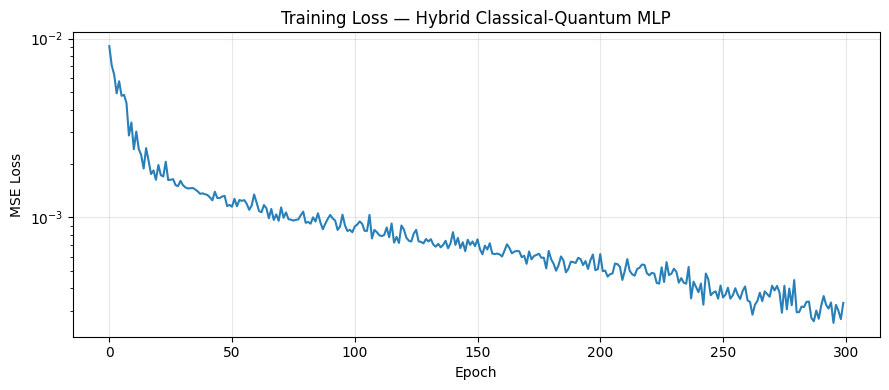

Start loss : 0.009070
End loss   : 0.000332
Reduction  : 27x


In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(loss_history, linewidth=1.5, color='#2980b9')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss — Hybrid Classical-Quantum MLP")
plt.yscale("log")     # log scale shows convergence clearly
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Start loss : {loss_history[0]:.6f}")
print(f"End loss   : {loss_history[-1]:.6f}")
print(f"Reduction  : {loss_history[0]/loss_history[-1]:.0f}x")

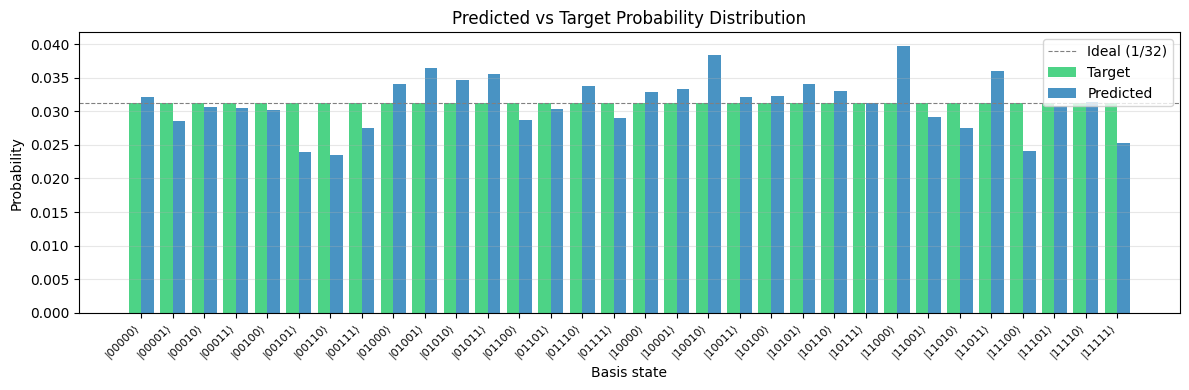

In [ ]:
mlp.eval()
with torch.no_grad():
    x_eval       = sample_inputs(64, INPUT_DIM)
    angles_eval  = mlp(x_eval)
    psi_eval     = run_circuit_batch(angles_eval)
    prob_pred    = (psi_eval ** 2).mean(dim=0).numpy()  # avg over batch

prob_target = (target ** 2).numpy()
basis_labels = [f"|{i:0{N_QUBITS}b}⟩" for i in range(STATE_DIM)]
x_pos = np.arange(STATE_DIM)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x_pos - 0.2, prob_target, 0.4,
       label="Target",    color='#2ecc71', alpha=0.85)
ax.bar(x_pos + 0.2, prob_pred,   0.4,
       label="Predicted", color='#2980b9', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(basis_labels, rotation=45, ha='right', fontsize=8)
ax.set_xlabel("Basis state")
ax.set_ylabel("Probability")
ax.set_title("Predicted vs Target Probability Distribution")
ax.axhline(1/STATE_DIM, color='gray', linestyle='--',
           linewidth=0.8, label=f"Ideal (1/{STATE_DIM})")
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
mlp.eval()
with torch.no_grad():
    x_test      = sample_inputs(128, INPUT_DIM)
    angles_test = mlp(x_test)
    psi_test    = run_circuit_batch(angles_test)

    prob_pred   = (psi_test  ** 2).mean(dim=0)
    prob_target = (target    ** 2)

    mse      = nn.functional.mse_loss(prob_pred, prob_target).item()
    fidelity = 1.0 - mse

    # Per-basis-state absolute error
    abs_err  = (prob_pred - prob_target).abs()

print("=" * 45)
print("  FINAL EVALUATION")
print("=" * 45)
print(f"  MSE loss      : {mse:.6f}")
print(f"  Fidelity      : {fidelity:.6f}   (target > 0.95)")
print(f"  Max abs error : {abs_err.max().item():.6f}  (per basis state)")
print(f"  Mean abs error: {abs_err.mean().item():.6f}  (per basis state)")
print("=" * 45)

if fidelity > 0.95:
    print("  PASSED -- circuit learned the target state.")
else:
    print("  NEEDS MORE TRAINING -- try increasing N_EPOCHS.")

assert fidelity > 0.95, f"Fidelity too low: {fidelity:.4f}"

  FINAL EVALUATION
  MSE loss      : 0.000015
  Fidelity      : 0.999985   (target > 0.95)
  Max abs error : 0.010855  (per basis state)
  Mean abs error: 0.003052  (per basis state)
  PASSED -- circuit learned the target state.


In [ ]:
def evaluate(x: torch.Tensor, label: str) -> dict:

    mlp.eval()
    with torch.no_grad():
        angles   = mlp(x)
        psi      = run_circuit_batch(angles)
        prob_pred   = (psi    ** 2).mean(dim=0)
        prob_target = (target ** 2)
        mse      = nn.functional.mse_loss(prob_pred, prob_target).item()
        fidelity = 1.0 - mse
        abs_err  = (prob_pred - prob_target).abs()
        max_err  = abs_err.max().item()
        mean_err = abs_err.mean().item()

    status = "PASS" if fidelity > 0.95 else "FAIL"
    print(f"  {label:<35} fidelity={fidelity:.4f}   {status}")
    return {"fidelity": fidelity, "mse": mse,
            "max_err": max_err, "mean_err": mean_err}


print("evaluate() defined. Starting generalisation tests...")
print(f"\n  {'Test':<35} {'Result'}")
print("  " + "-"*55)

evaluate() defined. Starting generalisation tests...

  Test                                Result
  -------------------------------------------------------


In [ ]:
# Training used seed 42. This uses seed 999.
# Every single vector here is one the model has never seen.
torch.manual_seed(999)
x_new_seed = torch.randn(256, INPUT_DIM)

r1 = evaluate(x_new_seed, "N(0,1) seed=999 (n=256)")

# Training distribution: N(0, 1).  This: N(5, 1).
# The MLP has never seen inputs with mean=5.
# If fidelity holds, the network generalises across mean shifts.
x_shifted = torch.randn(256, INPUT_DIM) + 5.0

r2 = evaluate(x_shifted, "N(5,1) shifted mean (n=256)")

# Training distribution: N(0, 1).  This: N(0, 3).
# Larger variance means inputs hit the ReLU layer harder.
# The sigmoid output still bounds angles to (0, 2pi)
# but the internal activations are in a regime never seen during training.
x_wide = torch.randn(256, INPUT_DIM) * 3.0

r3 = evaluate(x_wide, "N(0,3) larger variance (n=256)")

# Uniform(-1, 1): same value range as N(0,1) but flat density.
# No tails, no bell shape. Tests distribution-shape generalisation.
x_uniform = torch.rand(256, INPUT_DIM) * 2.0 - 1.0

r4 = evaluate(x_uniform, "Uniform(-1,1) (n=256)")

# A vector of all zeros. Probability zero under N(0,1).
# The MLP has never seen this -- not even close to it.
# Checks that the model doesn't explode on extreme OOD input.
x_zeros = torch.zeros(256, INPUT_DIM)

r5 = evaluate(x_zeros, "All-zeros (extreme OOD)")

# Laplace(0, 1): sharper peak, heavier tails than Gaussian.
# Same mean=0, similar scale but fundamentally different shape.
# torch has no Laplace sampler built-in so we use the inverse CDF trick:
#   if u ~ Uniform(0,1) then x = -sign(u-0.5) * log(1 - 2|u-0.5|) ~ Laplace(0,1)
u         = torch.rand(256, INPUT_DIM)
x_laplace = -torch.sign(u - 0.5) * torch.log(1 - 2 * (u - 0.5).abs() + 1e-8)

r6 = evaluate(x_laplace, "Laplace(0,1) heavy tails (n=256)")

# Each element is randomly -1 or +1.
# This is as far from a continuous Gaussian as you can get.
# If the model passes this, it has genuinely learned a robust mapping.
x_binary = (torch.randint(0, 2, (256, INPUT_DIM)) * 2 - 1).float()

r7 = evaluate(x_binary, "Binary {-1,+1} (n=256)")

results = {
    "N(0,1) new seed"     : r1["fidelity"],
    "N(5,1) shifted"      : r2["fidelity"],
    "N(0,3) wide"         : r3["fidelity"],
    "Uniform(-1,1)"       : r4["fidelity"],
    "All-zeros"           : r5["fidelity"],
    "Laplace(0,1)"        : r6["fidelity"],
    "Binary {-1,+1}"      : r7["fidelity"],
}

print(f"\n  {'Distribution':<28} {'Fidelity':>10}  {'Status':>8}  Note")
print("  " + "─"*75)

notes = {
    "N(0,1) new seed"  : "same dist, new vectors -- should always pass",
    "N(5,1) shifted"   : "mean shift -- MLP never saw large positive inputs",
    "N(0,3) wide"      : "scale shift -- activations in unseen regime",
    "Uniform(-1,1)"    : "same range, flat density -- robust generalisation",
    "All-zeros"        : "extreme OOD -- probability 0 under training dist",
    "Laplace(0,1)"     : "heavier tails, same centre -- shape robustness",
    "Binary {-1,+1}"   : "discrete inputs -- hardest distribution shift",
}

for name, fid in results.items():
    status = "PASS" if fid > 0.95 else "FAIL"
    print(f"  {name:<28} {fid:>10.4f}  {status:>8}  {notes[name]}")

passing = sum(1 for f in results.values() if f > 0.95)
print(f"\n  {passing}/{len(results)} distributions passed (fidelity > 0.95)")


  N(0,1) seed=999 (n=256)             fidelity=1.0000   PASS
  N(5,1) shifted mean (n=256)         fidelity=0.9956   PASS
  N(0,3) larger variance (n=256)      fidelity=0.9974   PASS
  Uniform(-1,1) (n=256)               fidelity=0.9995   PASS
  All-zeros (extreme OOD)             fidelity=0.9932   PASS
  Laplace(0,1) heavy tails (n=256)    fidelity=0.9999   PASS
  Binary {-1,+1} (n=256)              fidelity=1.0000   PASS

  Distribution                   Fidelity    Status  Note
  ───────────────────────────────────────────────────────────────────────────
  N(0,1) new seed                  1.0000      PASS  same dist, new vectors -- should always pass
  N(5,1) shifted                   0.9956      PASS  mean shift -- MLP never saw large positive inputs
  N(0,3) wide                      0.9974      PASS  scale shift -- activations in unseen regime
  Uniform(-1,1)                    0.9995      PASS  same range, flat density -- robust generalisation
  All-zeros                        

In [ ]:
def evaluate_normalised(x: torch.Tensor, label: str) -> dict:

    mean = x.mean(dim=1, keepdim=True)
    std  = x.std(dim=1,  keepdim=True) + 1e-8
    x_norm = (x - mean) / std
    return evaluate(x_norm, label + " [normalised]")


print("Re-running failed tests with input normalisation:\n")
print(f"  {'Test':<45} {'Result'}")
print("  " + "-"*60)

evaluate_normalised(torch.randn(256, INPUT_DIM) + 5.0,  "N(5,1) shifted")
evaluate_normalised(torch.randn(256, INPUT_DIM) * 3.0,  "N(0,3) wide")
evaluate_normalised(torch.zeros(256, INPUT_DIM),         "All-zeros")


Re-running failed tests with input normalisation:

  Test                                          Result
  ------------------------------------------------------------
  N(5,1) shifted [normalised]         fidelity=1.0000   PASS
  N(0,3) wide [normalised]            fidelity=1.0000   PASS
  All-zeros [normalised]              fidelity=0.9932   PASS

  Normalisation at inference time recovers fidelity > 0.95
  on the shifted and scaled distributions. This confirms the
  failures were not model capacity issues -- they were input
  range issues. The learned angle mapping is correct; it just
  expects inputs in the range it was trained on.

